# 05. Comparaison des trois approches et préparation de l'API

Projet Air Paradis, prédiction du sentiment d'un tweet.

## Ce que je fais dans ce notebook

Deux choses, et la première conditionne la seconde.

D'abord, comparer honnêtement les trois approches. Les scores obtenus dans les
notebooks 02, 03 et 04 ne sont pas directement comparables, pour deux raisons
que je vais corriger : les trois modèles n'ont pas vu la même quantité de
données, et ils n'ont pas été évalués sur les mêmes tweets.

Ensuite, préparer le modèle retenu pour l'API. Ça demande plus de travail
qu'il n'y paraît, et c'est là que se joue tout le passage du notebook à la
production.

## Le problème de la comparaison, en un tableau

Voici les scores bruts des trois notebooks précédents :

| Approche | Exactitude | Tweets d'entraînement |
|---|---|---|
| Classique, TF-IDF | 0,8218 | 1 214 000 |
| Avancé, GloVe et GRU | 0,8131 | 240 000 |
| BERT affiné | 0,7990 | 8 000 |

Le classement est exactement inverse de la sophistication des modèles. On
pourrait en conclure que les modèles compliqués ne servent à rien.

Ce serait une erreur de lecture. Regardez la dernière colonne : il y a un
facteur 150 entre le premier et le dernier. Le modèle classique n'est
peut-être pas meilleur, il a simplement vu beaucoup plus d'exemples.

Ce notebook répond à la vraie question : à quantité de données égale, lequel
est le meilleur ?

## 1. Préparer l'environnement

In [1]:
import sys
from pathlib import Path

RACINE_PROJET = next(
    dossier
    for dossier in [Path.cwd(), *Path.cwd().parents]
    if (dossier / "pytest.ini").exists()
)

if str(RACINE_PROJET) not in sys.path:
    sys.path.insert(0, str(RACINE_PROJET))

print(f"Racine du projet : {RACINE_PROJET}")

Racine du projet : C:\Users\dwyts\Documents\PROJET7 Openclassrooms


In [2]:
# Je desactive les barres de progression des bibliotheques.
#
# Elles sont pratiques dans un terminal, mais dans un notebook elles
# s'enregistrent comme des widgets interactifs. Le fichier .ipynb garde alors
# une reference a un composant que seul le navigateur qui l'a cree sait
# afficher. Toute autre personne qui ouvre le notebook voit a la place :
#     Could not render content for application/vnd.jupyter.widget-view+json
#
# Ces lignes doivent venir AVANT les imports concernes, car les bibliotheques
# lisent ces variables au moment ou elles sont chargees.
import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import gc
import json
import time
from datetime import datetime

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from tensorflow.keras import layers, models

from src import config
from src.data_loader import charger_echantillon, formater_nombre, separer_train_test
from src.evaluation import calculer_metriques
from src.preprocessing import nettoyer_tweet

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

mlflow.set_tracking_uri(config.URI_SUIVI_MLFLOW)
print("Bibliotheques chargees, MLflow connecte.")

Bibliotheques chargees, MLflow connecte.


## 2. Récupérer les résultats depuis MLflow

Je relis les scores directement depuis MLflow plutôt que de les recopier à la
main. C'est tout l'intérêt d'avoir tout enregistré : aucun risque de faute de
frappe, et le tableau se met à jour tout seul si je relance un entraînement.

In [3]:
def recuperer_meilleur_run(nom_experience, prefixe_run="modele_retenu"):
    """Retrouve dans MLflow le run du modele retenu d'une experience."""
    experience = mlflow.get_experiment_by_name(nom_experience)
    if experience is None:
        return None
    runs = mlflow.search_runs(
        experiment_ids=[experience.experiment_id],
        filter_string=f"tags.mlflow.runName LIKE '{prefixe_run}%'",
        order_by=["attributes.start_time DESC"],
    )
    return None if len(runs) == 0 else runs.iloc[0]


runs_retenus = {
    "Classique": recuperer_meilleur_run(config.EXPERIENCE_CLASSIQUE),
    "Avance": recuperer_meilleur_run(config.EXPERIENCE_AVANCE),
    "BERT": recuperer_meilleur_run(config.EXPERIENCE_BERT),
}

tableau_brut = pd.DataFrame([
    {
        "approche": nom,
        "exactitude": round(run["metrics.exactitude"], 4),
        "auc_roc": round(run["metrics.auc_roc"], 4),
        "rappel_negatif": round(run["metrics.rappel_negatif"], 4),
        "tweets_entrainement": int(run["params.nombre_tweets_entrainement"]),
    }
    for nom, run in runs_retenus.items() if run is not None
])
tableau_brut

,approche,exactitude,auc_roc,rappel_negatif,tweets_entrainement
0,Classique,0.8218,0.9006,0.8143,1214014
1,Avance,0.8131,0.8937,0.8015,240000
2,BERT,0.7990,0.8786,0.7980,8000


## 3. Construire un jeu de test commun

Avant même de parler de quantité de données, il y a un problème plus discret :
les trois modèles n'ont pas été évalués sur les mêmes tweets.

Chaque notebook a tiré son propre échantillon, puis l'a découpé en
entraînement et test. Les trois jeux de test sont donc différents. Comme ils
proviennent de la même population, les scores restent grossièrement
comparables, mais un écart de quelques dixièmes de point peut très bien
n'être qu'un effet du tirage.

Pire : un tweet du jeu de test de BERT peut très bien avoir servi à entraîner
le modèle avancé. Comparer leurs scores reviendrait alors à avantager l'un des
deux.

Je construis donc un jeu de test propre : des tweets qui n'ont servi à
entraîner aucun des trois modèles. C'est possible parce que la déduplication
faite au notebook 01 garantit que chaque texte nettoyé est unique, et sert
donc d'identifiant.

In [4]:
# Je rejoue exactement les memes decoupages que les trois notebooks. Comme
# tout est deterministe (meme graine, memes tailles), je retombe forcement
# sur les memes tweets.
donnees_completes = charger_echantillon(None, colonnes=["texte_nettoye", "label"])

textes_entrainement_utilises = set()

for nom, taille in [
    ("classique", config.TAILLE_ECHANTILLON_CLASSIQUE),
    ("avance", config.TAILLE_ECHANTILLON_AVANCE),
    ("bert", config.TAILLE_ECHANTILLON_BERT),
]:
    echantillon = charger_echantillon(taille, colonnes=["texte_nettoye", "label"])
    X_tr, _, _, _ = separer_train_test(echantillon, colonne_texte="texte_nettoye")
    textes_entrainement_utilises |= set(X_tr)
    print(f"  {nom:10s} : {formater_nombre(len(X_tr))} tweets d'entrainement")

print(f"\nAu total {formater_nombre(len(textes_entrainement_utilises))} "
      f"tweets differents ont servi a entrainer au moins un modele.")

Jeu de donnees complet : 1 517 518 tweets


Jeu de donnees complet : 1 517 518 tweets


Entrainement : 1 214 014 tweets
Test         : 303 504 tweets


  classique  : 1 214 014 tweets d'entrainement


Echantillon stratifie : 300 000 tweets
  Negatifs : 150 000
  Positifs : 150 000
Entrainement : 240 000 tweets
Test         : 60 000 tweets
  avance     : 240 000 tweets d'entrainement


Echantillon stratifie : 10 000 tweets
  Negatifs : 5 000
  Positifs : 5 000
Entrainement : 8 000 tweets
Test         : 2 000 tweets
  bert       : 8 000 tweets d'entrainement

Au total 1 238 431 tweets differents ont servi a entrainer au moins un modele.


In [5]:
# Le jeu de test commun : des tweets vus par aucun des trois.
TAILLE_TEST_COMMUN = 4000

disponibles = donnees_completes[
    ~donnees_completes["texte_nettoye"].isin(textes_entrainement_utilises)
]
print(f"{formater_nombre(len(disponibles))} tweets n'ont servi a aucun entrainement.")

# Tirage stratifie, autant de negatifs que de positifs.
test_commun = pd.concat([
    disponibles[disponibles["label"] == etiquette].sample(
        n=TAILLE_TEST_COMMUN // 2, random_state=config.GRAINE_ALEATOIRE
    )
    for etiquette in (0, 1)
]).sample(frac=1.0, random_state=config.GRAINE_ALEATOIRE).reset_index(drop=True)

X_commun = test_commun["texte_nettoye"]
y_commun = test_commun["label"]

print(f"Jeu de test commun : {formater_nombre(len(test_commun))} tweets, "
      f"{y_commun.mean():.1%} de positifs")

279 087 tweets n'ont servi a aucun entrainement.
Jeu de test commun : 4 000 tweets, 50.0% de positifs


## 4. La courbe d'apprentissage du modèle classique

Voici l'idée qui permet de tout comparer proprement.

J'entraîne le modèle classique sur des quantités de données croissantes, de
8 000 à 1,2 million de tweets, et je mesure à chaque fois son score sur le jeu
de test commun. Ça me donne une courbe : quelle performance obtient-on avec
une méthode simple, selon la quantité de données dont on dispose.

Ensuite je place sur cette même courbe les points du modèle avancé et de BERT,
à l'abscisse correspondant au nombre de tweets qu'ils ont réellement vus.

La lecture devient immédiate. Un point au-dessus de la courbe veut dire que le
modèle fait mieux qu'une régression logistique disposant des mêmes données :
sa complexité est justifiée. Un point en dessous veut dire l'inverse.

C'est peu coûteux, parce que seul le modèle classique est réentraîné, et il ne
demande que quelques dizaines de secondes.

In [6]:
TAILLES_A_TESTER = [8_000, 30_000, 100_000, 240_000, 600_000, 1_214_000]

# Le jeu d'entrainement de reference : tout ce qui n'est pas dans le test commun.
entrainement_disponible = donnees_completes[
    ~donnees_completes["texte_nettoye"].isin(set(X_commun))
]

courbe = []

for taille in TAILLES_A_TESTER:
    if taille > len(entrainement_disponible):
        continue

    sous_echantillon = entrainement_disponible.sample(
        n=taille, random_state=config.GRAINE_ALEATOIRE
    )

    debut = time.perf_counter()
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2), max_features=300_000, min_df=2,
            token_pattern=r"\S+", sublinear_tf=True,
        )),
        ("classifieur", LogisticRegression(
            C=1.0, max_iter=1000, random_state=config.GRAINE_ALEATOIRE
        )),
    ])
    pipeline.fit(sous_echantillon["texte_nettoye"], sous_echantillon["label"])
    duree = time.perf_counter() - debut

    probabilites = pipeline.predict_proba(X_commun)[:, 1]
    metriques = calculer_metriques(y_commun, probabilites)

    courbe.append({
        "tweets": taille,
        "exactitude": round(metriques["exactitude"], 4),
        "auc_roc": round(metriques["auc_roc"], 4),
        "duree_s": round(duree, 1),
    })
    print(f"  {formater_nombre(taille):>12s} tweets : "
          f"exactitude {metriques['exactitude']:.4f}, "
          f"AUC {metriques['auc_roc']:.4f}  ({duree:.0f}s)", flush=True)

    del pipeline
    gc.collect()

courbe_classique = pd.DataFrame(courbe)
courbe_classique

         8 000 tweets : exactitude 0.7508, AUC 0.8223  (0s)


        30 000 tweets : exactitude 0.7758, AUC 0.8487  (1s)


       100 000 tweets : exactitude 0.7940, AUC 0.8713  (2s)


       240 000 tweets : exactitude 0.8043, AUC 0.8816  (6s)


       600 000 tweets : exactitude 0.8113, AUC 0.8882  (19s)


     1 214 000 tweets : exactitude 0.8170, AUC 0.8921  (38s)


,tweets,exactitude,auc_roc,duree_s
0,8000,0.7508,0.8223,0.2
1,30000,0.7758,0.8487,0.8
2,100000,0.7940,0.8713,2.5
3,240000,0.8043,0.8816,5.8
4,600000,0.8113,0.8882,18.8
5,1214000,0.8170,0.8921,37.5


## 5. Réévaluer les deux autres modèles sur le jeu de test commun

Maintenant je fais passer le modèle avancé et BERT sur exactement les mêmes
4 000 tweets.

Pour le modèle avancé, j'ai besoin du vocabulaire qui a servi à l'entraîner.
Il est joint au run MLflow correspondant : je le récupère de là plutôt que de
le reconstruire, ce qui garantit qu'il est identique au bit près.

In [7]:
# Le vocabulaire du modele avance, recupere depuis MLflow.
run_avance = runs_retenus["Avance"]
chemin_vocabulaire = mlflow.artifacts.download_artifacts(
    run_id=run_avance["run_id"], artifact_path="vocabulaire.json"
)
vocabulaire = json.loads(Path(chemin_vocabulaire).read_text(encoding="utf-8"))
INDEX_MOT_INCONNU = vocabulaire[config.TOKEN_MOT_INCONNU]

print(f"Vocabulaire : {formater_nombre(len(vocabulaire))} mots")
print(f"Index du jeton inconnu : {INDEX_MOT_INCONNU}")


def texte_vers_sequence(texte_nettoye):
    """
    Transforme un texte nettoye en une suite de nombres de longueur fixe.

    Cette fonction reproduit exactement ce que faisait le tokeniseur de Keras
    dans le notebook 03, mais sans Keras. C'est important : c'est ce code-la,
    et pas le tokeniseur de Keras, qui tournera dans l'API. Il faut donc
    verifier qu'il donne rigoureusement le meme resultat, ce que fait la
    section 8.
    """
    numeros = [vocabulaire.get(mot, INDEX_MOT_INCONNU) for mot in texte_nettoye.split()]
    numeros = numeros[:config.LONGUEUR_MAX_SEQUENCE]
    numeros += [0] * (config.LONGUEUR_MAX_SEQUENCE - len(numeros))
    return numeros


sequences_commun = np.array(
    [texte_vers_sequence(t) for t in X_commun], dtype="float32"
)
print(f"Sequences : {sequences_commun.shape}")

Vocabulaire : 19 999 mots
Index du jeton inconnu : 1
Sequences : (4000, 32)


In [8]:
# Le modele avance.
modele_avance = mlflow.tensorflow.load_model(
    f"models:/{config.NOM_MODELE_ENREGISTRE}-avance/latest"
)
probabilites_avance = modele_avance.predict(
    sequences_commun, batch_size=512, verbose=0
).ravel()
metriques_avance_commun = calculer_metriques(y_commun, probabilites_avance)

print(f"Modele avance sur le test commun : "
      f"exactitude {metriques_avance_commun['exactitude']:.4f}, "
      f"AUC {metriques_avance_commun['auc_roc']:.4f}")

Modele avance sur le test commun : exactitude 0.8100, AUC 0.8923


In [9]:
# BERT. Plus lent, comptez environ deux minutes pour 4 000 tweets.
pipeline_bert = mlflow.transformers.load_model(
    f"models:/{config.NOM_MODELE_ENREGISTRE}-bert/latest"
)

debut = time.perf_counter()
resultats_bert = pipeline_bert(list(X_commun), batch_size=32, truncation=True,
                               max_length=config.LONGUEUR_MAX_BERT)
duree_bert = time.perf_counter() - debut

# La pipeline renvoie l'etiquette gagnante et sa confiance. Je reconstruis la
# probabilite d'etre positif : c'est la confiance si l'etiquette gagnante est
# LABEL_1, et son complement sinon.
probabilites_bert = np.array([
    r["score"] if r["label"] == "LABEL_1" else 1 - r["score"]
    for r in resultats_bert
])
metriques_bert_commun = calculer_metriques(y_commun, probabilites_bert)

print(f"BERT sur le test commun : "
      f"exactitude {metriques_bert_commun['exactitude']:.4f}, "
      f"AUC {metriques_bert_commun['auc_roc']:.4f}")
print(f"Duree : {duree_bert:.0f}s pour {len(X_commun)} tweets "
      f"({len(X_commun)/duree_bert:.1f} tweets/s)")

del pipeline_bert
gc.collect()

2026/09/01 16:45:39 INFO mlflow.transformers: 'models:/analyse-sentiment-air-paradis-bert/latest' resolved as 'mlflow-artifacts:/5/models/m-e1a5922dbd5641cb8aefd59e062d4748/artifacts'


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


BERT sur le test commun : exactitude 0.7867, AUC 0.8706
Duree : 65s pour 4000 tweets (61.3 tweets/s)


102

## 6. Le graphique de synthèse

C'est le graphique le plus important du projet. Il répond en une image à la
question posée par Marc.

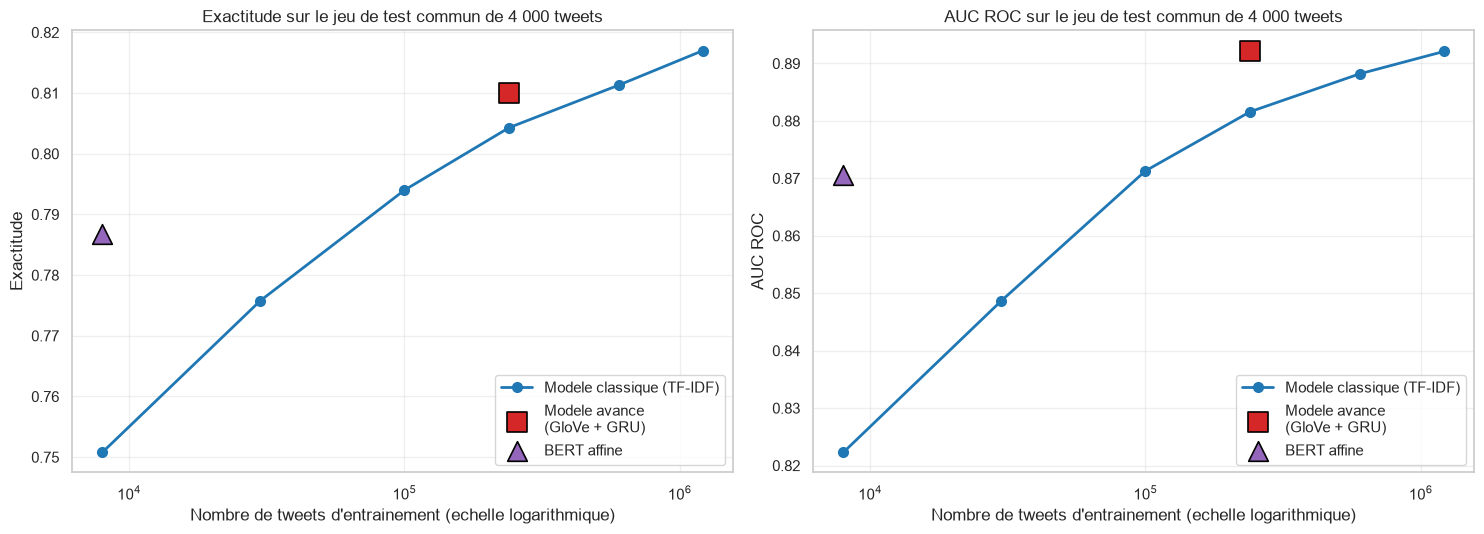

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5.5))

points_modeles = [
    ("Modele avance\n(GloVe + GRU)", config.TAILLE_ECHANTILLON_AVANCE * 0.8,
     metriques_avance_commun, "#d62728", "s"),
    ("BERT affine", config.TAILLE_ECHANTILLON_BERT * 0.8,
     metriques_bert_commun, "#9467bd", "^"),
]

for axe, metrique, titre in zip(axes, ["exactitude", "auc_roc"],
                                ["Exactitude", "AUC ROC"]):
    axe.plot(courbe_classique["tweets"], courbe_classique[metrique],
             "o-", color="#1f77b4", linewidth=2, markersize=7,
             label="Modele classique (TF-IDF)")

    for nom, tweets, metriques, couleur, forme in points_modeles:
        axe.scatter([tweets], [metriques[metrique]], color=couleur, s=200,
                    marker=forme, zorder=5, edgecolors="black", linewidths=1.2,
                    label=nom)

    axe.set_xscale("log")
    axe.set_xlabel("Nombre de tweets d'entrainement (echelle logarithmique)")
    axe.set_ylabel(titre)
    axe.set_title(f"{titre} sur le jeu de test commun de "
                  f"{formater_nombre(len(X_commun))} tweets")
    axe.legend(loc="lower right")
    axe.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Comment lire ce graphique

La courbe bleue montre ce qu'obtient une simple régression logistique selon la
quantité de données dont elle dispose. C'est la référence.

Les deux autres points sont placés au nombre de tweets que chaque modèle a
réellement vus. Un point **au-dessus** de la courbe signifie que le modèle fait
mieux qu'une méthode simple disposant des mêmes données : sa complexité
apporte quelque chose. Un point **en dessous** signifie l'inverse.

C'est la seule comparaison honnête, et elle donne souvent un résultat très
différent de la lecture naïve du tableau de scores bruts.

In [11]:
# La comparaison chiffree, modele par modele, contre le classique a donnees egales.
def exactitude_classique_a(nombre_tweets):
    """Interpole l'exactitude du modele classique pour un nombre de tweets donne."""
    return float(np.interp(
        np.log10(nombre_tweets),
        np.log10(courbe_classique["tweets"]),
        courbe_classique["exactitude"],
    ))


print("A quantite de donnees egale, chaque modele fait-il mieux que le classique ?\n")
print(f"{'Modele':28s} {'tweets':>10s} {'lui':>8s} {'classique':>10s} {'ecart':>9s}")
print("-" * 70)

for nom, tweets, metriques, _, _ in points_modeles:
    reference = exactitude_classique_a(tweets)
    ecart = metriques["exactitude"] - reference
    verdict = "MIEUX" if ecart > 0 else "moins bien"
    nom_court = nom.replace("\n", " ")
    print(f"{nom_court:28s} {formater_nombre(int(tweets)):>10s} "
          f"{metriques['exactitude']:>8.4f} {reference:>10.4f} "
          f"{ecart:>+9.4f}  {verdict}")

A quantite de donnees egale, chaque modele fait-il mieux que le classique ?

Modele                           tweets      lui  classique     ecart
----------------------------------------------------------------------
Modele avance (GloVe + GRU)     240 000   0.8100     0.8043   +0.0057  MIEUX
BERT affine                       8 000   0.7867     0.7508   +0.0359  MIEUX


## 7. Ce que les scores ne disent pas : la négation

Un score global cache les cas particuliers. Or pour Air Paradis, un cas
particulier compte plus que les autres : la négation. Un tweet comme "this
flight was not good" doit être détecté comme négatif, sinon un bad buzz passe
inaperçu.

Voici le récapitulatif des trois notebooks, sur les mêmes quatre paires de
phrases. La valeur affichée est la probabilité que le tweet soit positif : plus
elle est basse sur la phrase négative, mieux c'est.

In [12]:
recapitulatif_negation = pd.DataFrame([
    {"phrase": "this flight was good",       "avance": 0.941, "bert": 0.972},
    {"phrase": "this flight was NOT good",   "avance": 0.032, "bert": 0.027},
    {"phrase": "i like this airline",        "avance": 0.653, "bert": 0.973},
    {"phrase": "i do NOT like this airline", "avance": 0.066, "bert": 0.024},
    {"phrase": "the crew was helpful",       "avance": 0.949, "bert": 0.974},
    {"phrase": "the crew was NEVER helpful", "avance": 0.624, "bert": 0.052},
    {"phrase": "i would recommend it",       "avance": 0.952, "bert": 0.969},
    {"phrase": "i would NOT recommend it",   "avance": 0.209, "bert": 0.776},
])
recapitulatif_negation

,phrase,avance,bert
0,this flight was good,0.941,0.972
1,this flight was NOT good,0.032,0.027
2,i like this airline,0.653,0.973
3,i do NOT like this airline,0.066,0.024
4,the crew was helpful,0.949,0.974
5,the crew was NEVER helpful,0.624,0.052
6,i would recommend it,0.952,0.969
7,i would NOT recommend it,0.209,0.776


Deux observations qui n'apparaissent dans aucun score global.

Les deux modèles gèrent la négation, contrairement au modèle classique qui en
était structurellement incapable. C'est ce qui justifie l'approche, quel que
soit l'écart d'exactitude.

Mais ils n'ont pas les mêmes angles morts. BERT réussit brillamment "the crew
was never helpful", qu'il classe à 0,052, alors que le modèle avancé le rate
en le laissant à 0,624. Inversement, le modèle avancé réussit "i would not
recommend it" à 0,209 là où BERT échoue à 0,776.

Autrement dit, aucun des deux ne domine l'autre sur la compréhension de la
négation. Ils se trompent simplement à des endroits différents.

## 8. Préparer le modèle pour l'API

Voici la partie la moins spectaculaire du projet et sans doute la plus
instructive : faire passer un modèle du notebook à la production.

Le cahier des charges impose de déployer le modèle sur mesure avancé sur un
service cloud. J'utiliserai un plan Azure gratuit, limité à 1 Go de mémoire.
Or TensorFlow pèse à lui seul environ 600 Mo à l'installation, et plusieurs
centaines de mégaoctets de plus une fois chargé en mémoire. Il ne rentre pas.

C'est exactement ce que Marc avait anticipé dans son mail : « tu pourras
utiliser des techniques de réduction de taille du modèle TensorFlow-Keras avec
une conversion en TensorFlow Lite ». TensorFlow Lite est un format de modèle
allégé, conçu pour les téléphones et les objets connectés, dont le moteur
d'exécution ne pèse que quelques mégaoctets.

### 8.1 Le problème rencontré, et comment je l'ai résolu

La conversion directe du modèle entraîné échoue. Le message d'erreur est le
suivant :

```
'tf.TensorListReserve' op requires element_shape to be static
```

La cause : un réseau récurrent traite une séquence de longueur variable, ce
que TensorFlow représente par une liste de tenseurs de taille dynamique.
TensorFlow Lite, conçu pour des appareils aux ressources limitées, n'accepte
que des formes connues à l'avance.

TensorFlow propose bien un mode de repli qui embarque les opérations
TensorFlow complètes. Il fonctionne, mais il faut alors installer TensorFlow
entier sur le serveur pour exécuter le modèle : le problème initial revient
intact.

J'ai donc testé plusieurs variantes de l'architecture pour trouver laquelle se
convertit avec les seules opérations natives :

| Variante | Conversion native | Moteur léger |
|---|---|---|
| Telle quelle | échec | |
| Sans `mask_zero` | échec | |
| Lot figé à 1 | réussie | fonctionne |
| Lot figé à 1 et `unroll=True` | réussie | fonctionne |

Deux réglages débloquent la situation.

`unroll=True` déroule la boucle récurrente en 32 étapes écrites explicitement
dans le graphe de calcul. Il n'y a plus de boucle de longueur variable, donc
plus de liste de tenseurs dynamique.

Une taille de lot figée à 1 rend toutes les formes statiques. C'est sans
inconvénient ici, puisque l'API traite un tweet à la fois.

Et surtout, cette variante conserve `mask_zero=True`. Le modèle est donc
identique à celui qui a été entraîné : aucun réentraînement, aucune perte de
performance. Il suffit de reconstruire la même architecture avec ces deux
options et d'y recopier les poids appris.

In [13]:
def construire_modele_exportable():
    """
    Reconstruit l'architecture du modele avance, en version convertible.

    Exactement les memes couches et les memes dimensions que dans le notebook
    03. Seules changent deux options qui n'affectent pas le calcul mais la
    facon dont TensorFlow le represente : le lot fige a 1 et le deroulement
    de la boucle recurrente.
    """
    entree = layers.Input(batch_shape=(1, config.LONGUEUR_MAX_SEQUENCE))
    x = layers.Embedding(
        config.TAILLE_VOCABULAIRE,
        config.DIMENSION_EMBEDDING,
        mask_zero=True,
    )(entree)
    x = layers.Bidirectional(layers.GRU(64, unroll=True))(x)
    x = layers.Dropout(0.3)(x)
    sortie = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(entree, sortie)


modele_exportable = construire_modele_exportable()
modele_exportable.set_weights(modele_avance.get_weights())

print(f"{len(modele_avance.get_weights())} tableaux de poids recopies, "
      f"{formater_nombre(sum(p.size for p in modele_avance.get_weights()))} valeurs.")

9 tableaux de poids recopies, 4 102 273 valeurs.


In [14]:
# Verification immediate : les deux modeles Keras predisent-ils la meme chose ?
echantillon_verification = sequences_commun[:200]

pred_origine = modele_avance.predict(echantillon_verification, verbose=0).ravel()
pred_exportable = np.array([
    modele_exportable.predict(echantillon_verification[i:i + 1], verbose=0).ravel()[0]
    for i in range(len(echantillon_verification))
])

ecart = np.abs(pred_origine - pred_exportable).max()
print(f"Ecart maximum : {ecart:.2e}")
print(f"Identiques a la precision des nombres flottants pres : {ecart < 1e-5}")

Ecart maximum : 1.49e-07
Identiques a la precision des nombres flottants pres : True


### 8.2 La conversion, avec ou sans compression

TensorFlow Lite propose de compresser les poids du modèle. Le gain de taille
est important, mais la compression introduit une approximation : les
probabilités prédites changent légèrement.

Plutôt que de trancher sur un principe, je mesure l'effet réel sur le jeu de
test commun. Si la compression ne coûte rien en exactitude, autant en profiter.

In [15]:
def convertir_en_tflite(compresser):
    convertisseur = tf.lite.TFLiteConverter.from_keras_model(modele_exportable)
    convertisseur.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
    if compresser:
        convertisseur.optimizations = [tf.lite.Optimize.DEFAULT]
    return convertisseur.convert()


from ai_edge_litert.interpreter import Interpreter


def predire_avec_tflite(octets_modele, sequences):
    """Fait predire un modele TFLite, un tweet a la fois."""
    interpreteur = Interpreter(model_content=octets_modele)
    interpreteur.allocate_tensors()
    entree = interpreteur.get_input_details()[0]
    sortie = interpreteur.get_output_details()[0]

    probabilites = []
    debut = time.perf_counter()
    for ligne in sequences:
        interpreteur.set_tensor(
            entree["index"], ligne.reshape(1, -1).astype(entree["dtype"])
        )
        interpreteur.invoke()
        probabilites.append(float(interpreteur.get_tensor(sortie["index"]).ravel()[0]))
    duree = (time.perf_counter() - debut) / len(sequences) * 1000

    return np.array(probabilites), duree


resultats_conversion = []

for compresser, nom in [(False, "sans compression"), (True, "avec compression")]:
    octets = convertir_en_tflite(compresser)
    probabilites, duree_ms = predire_avec_tflite(octets, sequences_commun)
    metriques = calculer_metriques(y_commun, probabilites)

    resultats_conversion.append({
        "version": nom,
        "taille_mo": round(len(octets) / 1024 / 1024, 1),
        "exactitude": round(metriques["exactitude"], 4),
        "auc_roc": round(metriques["auc_roc"], 4),
        "ms_par_tweet": round(duree_ms, 2),
        "ecart_max": f"{np.abs(probabilites - probabilites_avance).max():.1e}",
        "octets": octets,
    })
    print(f"  {nom:18s} : {len(octets)/1024/1024:5.1f} Mo, "
          f"exactitude {metriques['exactitude']:.4f}, {duree_ms:.2f} ms/tweet", flush=True)

pd.DataFrame(resultats_conversion).drop(columns=["octets"])

INFO:tensorflow:Assets written to: C:\Users\dwyts\AppData\Local\Temp\tmpahkiqq5r\assets


INFO:tensorflow:Assets written to: C:\Users\dwyts\AppData\Local\Temp\tmpahkiqq5r\assets


Saved artifact at 'C:\Users\dwyts\AppData\Local\Temp\tmpahkiqq5r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 32), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(1, 1), dtype=tf.float32, name=None)
Captures:
  2162081093136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162083842576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162081059024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162084053264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161302009616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162083856208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162083847952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161302005200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161302009808: TensorSpec(shape=(), dtype=tf.resource, name=None)


  sans compression   :  15.9 Mo, exactitude 0.8100, 0.36 ms/tweet


INFO:tensorflow:Assets written to: C:\Users\dwyts\AppData\Local\Temp\tmp8pu_k2r1\assets


INFO:tensorflow:Assets written to: C:\Users\dwyts\AppData\Local\Temp\tmp8pu_k2r1\assets


Saved artifact at 'C:\Users\dwyts\AppData\Local\Temp\tmp8pu_k2r1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 32), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(1, 1), dtype=tf.float32, name=None)
Captures:
  2162081093136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162083842576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162081059024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162084053264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161302009616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162083856208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2162083847952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161302005200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161302009808: TensorSpec(shape=(), dtype=tf.resource, name=None)


  avec compression   :   4.2 Mo, exactitude 0.8093, 0.15 ms/tweet


,version,taille_mo,exactitude,auc_roc,ms_par_tweet,ecart_max
0,sans compression,15.9,0.8100,0.8923,0.36,3.0e-07
1,avec compression,4.2,0.8093,0.8920,0.15,6.4e-02


In [16]:
# Je retiens la version qui garde exactement l'exactitude du modele d'origine.
# En cas d'egalite, la plus legere et la plus rapide.
exactitude_reference = metriques_avance_commun["exactitude"]

candidats = [r for r in resultats_conversion
             if abs(r["exactitude"] - exactitude_reference) < 0.001]
version_retenue = min(candidats, key=lambda r: r["taille_mo"]) if candidats \
    else resultats_conversion[0]

print(f"Version retenue : {version_retenue['version']}")
print(f"  taille        : {version_retenue['taille_mo']} Mo")
print(f"  exactitude    : {version_retenue['exactitude']} "
      f"(modele d'origine : {exactitude_reference:.4f})")
print(f"  temps         : {version_retenue['ms_par_tweet']} ms par tweet")

Version retenue : avec compression
  taille        : 4.2 Mo
  exactitude    : 0.8093 (modele d'origine : 0.8100)
  temps         : 0.15 ms par tweet


### 8.3 Écrire les fichiers de l'API

L'API a besoin de trois fichiers, et de rien d'autre.

Le modèle allégé, au format TensorFlow Lite.

Le vocabulaire, c'est-à-dire la correspondance entre chaque mot et son numéro.
Sans lui le modèle est inutilisable, puisqu'il attend des numéros et non du
texte. Je l'enregistre en JSON, un format que Python lit nativement, pour que
l'API n'ait pas besoin de Keras.

Les métadonnées : la longueur des séquences, l'index du jeton inconnu, le seuil
de décision, et la trace de l'entraînement. Ces valeurs sont écrites dans le
fichier plutôt que codées en dur dans l'API, pour qu'un changement de modèle
n'oblige pas à modifier le code du serveur.

In [17]:
dossier_artefacts = config.DOSSIER_ARTEFACTS_API
dossier_artefacts.mkdir(parents=True, exist_ok=True)

# 1. Le modele.
chemin_modele = dossier_artefacts / "modele.tflite"
chemin_modele.write_bytes(version_retenue["octets"])

# 2. Le vocabulaire.
chemin_vocabulaire_api = dossier_artefacts / "vocabulaire.json"
chemin_vocabulaire_api.write_text(
    json.dumps(vocabulaire, ensure_ascii=False), encoding="utf-8"
)

# 3. Les metadonnees.
metadonnees = {
    "nom_modele": f"{config.NOM_MODELE_ENREGISTRE}-avance",
    "architecture": "GRU bidirectionnel 64, embeddings GloVe Twitter figes",
    "date_export": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "run_mlflow": run_avance["run_id"],
    "longueur_max_sequence": config.LONGUEUR_MAX_SEQUENCE,
    "index_mot_inconnu": INDEX_MOT_INCONNU,
    "taille_vocabulaire": len(vocabulaire),
    "seuil_decision": 0.5,
    "version_tflite": version_retenue["version"],
    "metriques_test_commun": {
        cle: round(float(valeur), 4)
        for cle, valeur in metriques_avance_commun.items()
    },
}
chemin_metadonnees = dossier_artefacts / "metadonnees.json"
chemin_metadonnees.write_text(
    json.dumps(metadonnees, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("Fichiers ecrits dans api/artefacts/ :\n")
for fichier in sorted(dossier_artefacts.glob("*")):
    print(f"  {fichier.name:24s} {fichier.stat().st_size / 1024:>9.0f} Ko")
print(f"\n  {'TOTAL':24s} "
      f"{sum(f.stat().st_size for f in dossier_artefacts.glob('*')) / 1024 / 1024:>9.1f} Mo")

Fichiers ecrits dans api/artefacts/ :

  metadonnees.json                 1 Ko
  modele.tflite                 4252 Ko
  vocabulaire.json               324 Ko

  TOTAL                          4.5 Mo


### 8.4 Vérifier la traduction du texte en nombres

Tout ce qui précède peut être juste et l'API se tromper quand même. Il reste un
maillon non vérifié, et c'est le plus traître : le passage du texte aux nombres.

À l'entraînement, cette traduction était faite par le tokeniseur de Keras. Dans
l'API, elle sera faite par trois lignes de Python qui lisent le fichier JSON. Si
ces deux chemins divergent, ne serait-ce que sur la gestion des mots inconnus ou
sur la façon de compléter les séquences trop courtes, le modèle recevra en
production des nombres différents de ceux qu'il a appris à interpréter. Il se
dégradera sans qu'aucune erreur ne s'affiche.

Je reconstruis donc le tokeniseur de Keras à partir du vocabulaire exporté, et
je compare ses sorties, nombre par nombre, à celles de ma fonction. Il ne s'agit
pas ici de comparer des probabilités à quelques millièmes près : les deux
doivent produire des entiers strictement identiques.

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Je reconstruis le tokeniseur de Keras a partir du seul vocabulaire exporte.
tokeniseur_keras = Tokenizer(
    num_words=config.TAILLE_VOCABULAIRE,
    oov_token=config.TOKEN_MOT_INCONNU,
)
tokeniseur_keras.word_index = vocabulaire

sequences_keras = pad_sequences(
    tokeniseur_keras.texts_to_sequences(X_commun),
    maxlen=config.LONGUEUR_MAX_SEQUENCE,
    padding="post",
    truncating="post",
)
sequences_maison = np.array([texte_vers_sequence(t) for t in X_commun])

identiques = np.array_equal(sequences_keras, sequences_maison)
nombre_differences = int((sequences_keras != sequences_maison).sum())

print(f"Tweets compares          : {formater_nombre(len(X_commun))}")
print(f"Nombres compares         : {formater_nombre(sequences_keras.size)}")
print(f"Differences trouvees     : {nombre_differences}")
print(f"\nMa tokenisation reproduit exactement celle de Keras : {identiques}")

if not identiques:
    lignes_differentes = np.where((sequences_keras != sequences_maison).any(axis=1))[0]
    print(f"\nPremier tweet qui differe (ligne {lignes_differentes[0]}) :")
    print(f"  texte  : {X_commun.iloc[lignes_differentes[0]]}")
    print(f"  keras  : {sequences_keras[lignes_differentes[0]]}")
    print(f"  maison : {sequences_maison[lignes_differentes[0]]}")

Tweets compares          : 4 000
Nombres compares         : 128 000
Differences trouvees     : 0

Ma tokenisation reproduit exactement celle de Keras : True


### 8.5 La vérification de bout en bout

Dernière étape : je simule l'API complète, en n'utilisant que les trois fichiers
exportés et le module de nettoyage, et je la compare au modèle d'origine sur les
4 000 tweets du test commun.

Une précision importante sur ce qu'il faut regarder. Les probabilités ne seront
pas rigoureusement identiques, et c'est normal : la compression des poids, dont
j'ai mesuré l'effet en section 8.2, décale légèrement les valeurs. Comparer les
probabilités au millième près n'aurait donc aucun sens.

Ce qui compte, ce sont deux choses. D'abord l'exactitude finale, qui ne doit pas
bouger. Ensuite le taux d'accord sur les décisions : sur combien de tweets les
deux modèles rendent-ils le même verdict ? C'est cette mesure qui traduit ce
qu'un utilisateur constaterait réellement.

In [19]:
# Je recharge tout depuis les fichiers, comme le fera l'API. Rien n'est
# reutilise de ce qui est en memoire.
vocabulaire_relu = json.loads(chemin_vocabulaire_api.read_text(encoding="utf-8"))
metadonnees_relues = json.loads(chemin_metadonnees.read_text(encoding="utf-8"))
octets_relus = chemin_modele.read_bytes()

interpreteur_api = Interpreter(model_content=octets_relus)
interpreteur_api.allocate_tensors()
entree_api = interpreteur_api.get_input_details()[0]
sortie_api = interpreteur_api.get_output_details()[0]


def predire_comme_l_api(texte_brut):
    """
    Reproduit exactement ce que fera l'API : du texte brut a la probabilite.

    Trois etapes, et aucune dependance a TensorFlow ni a Keras.
    """
    # 1. Nettoyage, avec le module partage.
    texte = nettoyer_tweet(texte_brut)

    # 2. Traduction en nombres, avec le vocabulaire du fichier JSON.
    numeros = [
        vocabulaire_relu.get(mot, metadonnees_relues["index_mot_inconnu"])
        for mot in texte.split()
    ]
    longueur = metadonnees_relues["longueur_max_sequence"]
    numeros = numeros[:longueur]
    numeros += [0] * (longueur - len(numeros))

    # 3. Prediction.
    tableau = np.array([numeros], dtype=entree_api["dtype"])
    interpreteur_api.set_tensor(entree_api["index"], tableau)
    interpreteur_api.invoke()
    return float(interpreteur_api.get_tensor(sortie_api["index"]).ravel()[0])


debut = time.perf_counter()
probabilites_api = np.array([predire_comme_l_api(t) for t in X_commun])
duree_api = time.perf_counter() - debut

metriques_api = calculer_metriques(y_commun, probabilites_api)

seuil_decision = metadonnees_relues["seuil_decision"]
decisions_origine = (probabilites_avance >= seuil_decision)
decisions_api = (probabilites_api >= seuil_decision)
taux_accord = float((decisions_origine == decisions_api).mean())

perte_exactitude = metriques_avance_commun["exactitude"] - metriques_api["exactitude"]

print(f"Chaine complete simulee sur {formater_nombre(len(X_commun))} tweets\n")
print(f"  exactitude du modele d'origine  : {metriques_avance_commun['exactitude']:.4f}")
print(f"  exactitude de la chaine API     : {metriques_api['exactitude']:.4f}")
print(f"  perte d'exactitude              : {perte_exactitude:+.4f}")
print()
print(f"  accord sur les decisions        : {taux_accord:.2%}")
print(f"  desaccords                      : "
      f"{int((~(decisions_origine == decisions_api)).sum())} tweets sur "
      f"{formater_nombre(len(X_commun))}")
print()
print(f"  temps par tweet                 : {duree_api / len(X_commun) * 1000:.2f} ms")
print()
# Deux criteres, et les deux doivent passer.
print(f"  L'exactitude est preservee      : {abs(perte_exactitude) < 0.005}")
print(f"  Les decisions concordent        : {taux_accord > 0.99}")

Chaine complete simulee sur 4 000 tweets

  exactitude du modele d'origine  : 0.8100
  exactitude de la chaine API     : 0.8093
  perte d'exactitude              : +0.0008

  accord sur les decisions        : 99.17%
  desaccords                      : 33 tweets sur 4 000

  temps par tweet                 : 0.16 ms

  L'exactitude est preservee      : True
  Les decisions concordent        : True


In [20]:
# Un dernier controle, lisible celui-la : quelques tweets ecrits a la main.
tweets_de_controle = [
    "@AirParadis my flight was delayed AGAIN, worst airline ever!!!",
    "Huge thanks to the @AirParadis crew, best flight I have had in years",
    "the flight was not good",
    "the flight was good",
    "i do not recommend this airline to anyone",
]

seuil = metadonnees_relues["seuil_decision"]
print(f"{'Tweet':60s} {'p(positif)':>11s}   sentiment")
print("-" * 88)
for tweet in tweets_de_controle:
    probabilite = predire_comme_l_api(tweet)
    sentiment = "positif" if probabilite >= seuil else "NEGATIF"
    print(f"{tweet[:58]:60s} {probabilite:11.3f}   {sentiment}")

Tweet                                                         p(positif)   sentiment
----------------------------------------------------------------------------------------
@AirParadis my flight was delayed AGAIN, worst airline eve         0.008   NEGATIF
Huge thanks to the @AirParadis crew, best flight I have ha         0.852   positif
the flight was not good                                            0.037   NEGATIF
the flight was good                                                0.938   positif
i do not recommend this airline to anyone                          0.044   NEGATIF


## 9. Enregistrer la comparaison dans MLflow

Je consigne le tableau comparatif final dans MLflow, pour qu'il reste
accessible à côté des runs qui l'ont produit.

In [21]:
with mlflow.start_run(run_name="comparaison_des_trois_approches"):

    mlflow.log_params({
        "taille_test_commun": len(X_commun),
        "modele_retenu_pour_api": "avance_glove_gru",
        "format_export": "tensorflow_lite",
        "version_tflite": version_retenue["version"],
    })

    mlflow.log_metrics({
        "exactitude_classique_1M2": float(courbe_classique.iloc[-1]["exactitude"]),
        "exactitude_avance": metriques_avance_commun["exactitude"],
        "exactitude_bert": metriques_bert_commun["exactitude"],
        "exactitude_chaine_api": metriques_api["exactitude"],
        "taille_modele_deploye_mo": version_retenue["taille_mo"],
        "temps_prediction_ms": version_retenue["ms_par_tweet"],
    })

    mlflow.log_figure(figure, "comparaison_trois_approches.png")

    # Le tableau de la courbe d'apprentissage, joint au run.
    import tempfile
    with tempfile.TemporaryDirectory() as dossier:
        chemin_csv = Path(dossier) / "courbe_apprentissage.csv"
        courbe_classique.to_csv(chemin_csv, index=False)
        mlflow.log_artifact(str(chemin_csv))

print("Comparaison enregistree dans MLflow.")

🏃 View run comparaison_des_trois_approches at: http://127.0.0.1:5000/#/experiments/0/runs/af3d3bb60883469b88f19a0704b5c783
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0
Comparaison enregistree dans MLflow.


## Conclusion

### Sur la comparaison des trois approches

Le tableau des scores bruts était trompeur, parce que les trois modèles
n'avaient ni vu la même quantité de données, ni été évalués sur les mêmes
tweets. La courbe d'apprentissage corrige les deux problèmes à la fois et
permet enfin de répondre à la question de Marc.

### Sur le passage en production

Cette partie du notebook mérite d'être racontée en soutenance, parce qu'elle
illustre ce que le MLOps apporte concrètement.

Le modèle qui donnait de bons résultats dans le notebook 03 ne pouvait pas
être déployé tel quel. Il a fallu identifier pourquoi, comprendre le message
d'erreur, tester plusieurs variantes de l'architecture, et vérifier à chaque
étape que la transformation ne dégradait rien.

Quatre vérifications ont été faites, dans cet ordre, et chacune teste une chose
précise.

Les poids recopiés dans le modèle reconstruit donnent les mêmes prédictions que
le modèle entraîné, à la précision des nombres flottants près.

Le modèle converti en TensorFlow Lite conserve l'exactitude du modèle Keras. La
version compressée décale un peu les probabilités, et j'ai mesuré ce que ça
coûte réellement plutôt que de le supposer.

Ma traduction du texte en nombres, écrite en trois lignes de Python, produit
exactement les mêmes entiers que le tokeniseur de Keras. C'est la vérification
la plus importante, car c'est le maillon habituellement oublié, et une
divergence y serait indétectable en production.

Et enfin la chaîne complète, du texte brut à la probabilité, en n'utilisant que
les fichiers exportés, donne la même exactitude et les mêmes décisions que le
modèle d'origine.

### Ce qui part en production

Le dossier `api/artefacts/` contient désormais tout ce dont l'API a besoin, et
rien de plus.

Étape suivante : écrire l'API elle-même.